In [220]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, LeakyReLU, Flatten, Dense, Reshape
from tensorflow.keras.optimizers import Adam
K = tf.keras.backend
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.callbacks import Callback

Generated dataset shapes:
X_train shape: (1600, 48, 128, 1)
y_train shape: (1600, 5, 5)


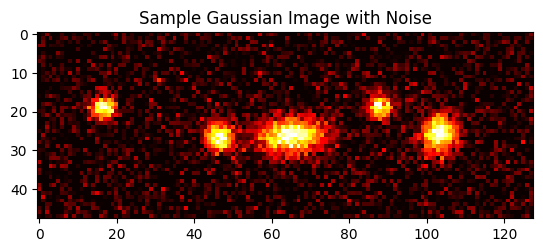

Sample Gaussian parameters (mean_x, mean_y, cov_x, cov_y, theta):
[[ 1.6797436e+01  1.9061323e+01  2.2738018e+00  2.3093610e+00
  -1.4931010e-01]
 [ 4.6492451e+01  2.6487709e+01  2.5255556e+00  2.6640723e+00
  -1.7169908e-01]
 [ 6.5340088e+01  2.6274073e+01  5.9260416e+00  3.3773668e+00
  -6.5369144e-02]
 [ 8.7912270e+01  1.8871077e+01  2.1495347e+00  2.2952812e+00
  -7.5925678e-02]
 [ 1.0345501e+02  2.5783678e+01  3.0758579e+00  3.6673222e+00
   2.6040204e-02]]


In [221]:
def generate_gaussian_blob(image_size, mean, cov, angle, noise_std=0.01):
    """
    Generate a single Gaussian blob on an image with added random noise.
    """
    x, y = np.meshgrid(np.linspace(0, image_size[0] - 1, image_size[0]),
                       np.linspace(0, image_size[1] - 1, image_size[1]))
    x -= mean[0]
    y -= mean[1]

    cos_angle = np.cos(angle)
    sin_angle = np.sin(angle)

    x_rot = cos_angle * x + sin_angle * y
    y_rot = -sin_angle * x + cos_angle * y

    exponent = (x_rot ** 2) / (2 * cov[0] ** 2) + (y_rot ** 2) / (2 * cov[1] ** 2)
    blob = np.exp(-exponent)

    # Add random noise centered around the Gaussian blob
    noise = np.random.normal(0, noise_std, blob.shape)
    blob += noise

    return blob

def convert_parameters(parameters):
    """
    Convert Gaussian parameters from (amplitude, x0, y0, sigma_x, sigma_y) to (mean_x, mean_y, cov_x, cov_y, theta).
    """
    A, x0, y0, sigma_x, sigma_y = parameters
    
    mean_x = x0
    mean_y = y0
    cov_x = sigma_x
    cov_y = sigma_y
    
    # Calculate theta from the covariance values
    if cov_x != 0 and cov_y != 0:
        theta = 0.5 * np.arctan2(2 * cov_x * cov_y, (cov_x**2 - cov_y**2))
    else:
        theta = 0.0
    
    return mean_x, mean_y, cov_x, cov_y, theta

def create_training_data(num_samples, image_size=(128, 48), num_blobs=5, noise_std=0.05):
    """
    Create training data with Gaussian blobs and noise for the YOLO-style model.
    """
    X = np.zeros((num_samples, image_size[1], image_size[0], 1), dtype=np.float32)
    y = np.zeros((num_samples, num_blobs, 5), dtype=np.float32)

    for i in range(num_samples):
        image = np.zeros((image_size[1], image_size[0]), dtype=np.float32)
        blob_params = []

        # Generate y-values within 20% of each other
        base_y = np.random.uniform(0.4 * image_size[1], 0.6 * image_size[1])
        y_values = np.random.uniform(base_y * 0.8, base_y * 1.2, num_blobs)

        # Generate evenly spaced x-values with slight variation
        x_values = np.linspace(0, image_size[0], num_blobs + 2)[1:-1]
        x_values += np.random.uniform(-5, 5, num_blobs)

        for j in range(num_blobs):
            mean_x = x_values[j]
            mean_y = y_values[j]
            cov_x = np.random.uniform(2, 6)
            cov_y = np.random.uniform(1, 5)
            theta = np.random.uniform(-10, 10) * np.pi / 180  # Cap rotation at 10 degrees

            blob = generate_gaussian_blob((image_size[0], image_size[1]), (mean_x, mean_y), (cov_x, cov_y), theta, noise_std)
            image += blob

            # Store parameters for the label
            blob_params.append((mean_x, mean_y, cov_x, cov_y, theta))

        # Convert parameters to labels
        for j in range(num_blobs):
            mean_x, mean_y, cov_x, cov_y, theta = blob_params[j]
            y[i, j, :] = [mean_x, mean_y, cov_x, cov_y, theta]

        X[i, :, :, 0] = np.clip(image, 0, 1)

    return X, y

# num_samples = 1  # Number of training samples
# X_train, y_train = create_training_data(num_samples, noise_std=0.05)

print("Generated dataset shapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
plt.imshow(X_train[0].squeeze(), cmap='hot')
plt.title("Sample Gaussian Image with Noise")
plt.show()
print("Sample Gaussian parameters (mean_x, mean_y, cov_x, cov_y, theta):")
print(y_train[0])

In [222]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class CropLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(CropLayer, self).__init__(**kwargs)

    def call(self, inputs):
        image, crop_boxes = inputs
        batch_size = tf.shape(image)[0]
        num_boxes = tf.shape(crop_boxes)[1]
        crop_boxes = tf.reshape(crop_boxes, (batch_size * num_boxes, 4))  # Flatten the crop_boxes tensor
        box_indices = tf.range(batch_size)
        box_indices = tf.repeat(box_indices, repeats=num_boxes)
        
        cropped_images = tf.image.crop_and_resize(
            image, crop_boxes, box_indices, (20, 20)
        )
        
        # Explicitly reshape to (batch_size, num_boxes, 20, 20, channels)
        num_channels = tf.shape(image)[-1]
        cropped_images = tf.reshape(cropped_images, (batch_size, num_boxes, 20, 20, num_channels))
        return cropped_images

def create_shared_layers():
    """Create the layers that will be reused across all cropped images."""
    model_layers = [
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(axis=-1),
        layers.MaxPooling2D(pool_size=2, strides=2),
        
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(axis=-1),
        layers.MaxPooling2D(pool_size=2, strides=2),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(5, activation=None)  # Predict 5 Gaussian parameters
    ]
    return model_layers

def apply_shared_layers(cropped_image, shared_layers):
    """Pass the cropped image through the shared layers."""
    x = cropped_image
    for layer in shared_layers:
        x = layer(x)
    return x

def GaussianFitter(input_shape):
    # Input layer
    inputs = layers.Input(shape=input_shape)
   
    # Initial convolutions to process the full image
    x = layers.Conv2D(8, kernel_size=3, activation='relu', strides=2, padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(16, kernel_size=3, activation='relu', strides=2, padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
   
    # Predict 5 crop areas
    crop_pred = layers.Conv2D(16, kernel_size=3, activation='relu', padding='same')(x)
    crop_pred = layers.Flatten()(crop_pred)
    crop_pred = layers.Dense(64, activation='relu')(crop_pred)
    crop_pred = layers.Dense(5 * 4, activation='sigmoid', name='crop_prediction')(crop_pred)
   
    # Reshape crop predictions to [batch_size, 5, 4] format
    crop_boxes = layers.Reshape((5, 4))(crop_pred)
   
    # Crop the original input image
    cropped_images = CropLayer()([inputs, crop_boxes])

    # Create a shared set of layers
    shared_layers = create_shared_layers()

    # Process each cropped image using the shared layers
    gaussian_params_list = []
    for i in range(5):
        cropped_image = cropped_images[:, i, :, :, :]  # Select the i-th cropped image
        gaussian_params = apply_shared_layers(cropped_image, shared_layers)  # Process using shared layers
        gaussian_params_list.append(gaussian_params)

    # Stack the predictions from all cropped images
    gaussian_params_output = layers.Lambda(lambda x: tf.stack(x, axis=1))(gaussian_params_list)

    # Model
    model = Model(inputs=inputs, outputs=[gaussian_params_output, crop_pred])
    return model

# Example usage
input_shape = (48, 128, 1)
model = GaussianFitter(input_shape)
model.summary()

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_42      │ (None, 48, 128,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_220 (Conv2D) │ (None, 24, 64, 8) │         80 │ input_layer_42[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_168   │ (None, 12, 32, 8) │          0 │ conv2d_220[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_221 (Conv2D) │ (None, 6, 16, 16) │      1,168 │ max_pooling2d_16… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_169   │ (None, 3, 8, 16)  │          0 │ conv2d_221[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_222 (Conv2D) │ (None, 3, 8, 16)  │      2,320 │ max_pooling2d_16… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_79          │ (None, 384)       │          0 │ conv2d_222[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_118 (Dense)   │ (None, 64)        │     24,640 │ flatten_79[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_prediction     │ (None, 20)        │      1,300 │ dense_118[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_69          │ (None, 5, 4)      │          0 │ crop_prediction[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_layer_52       │ (None, 5, 20, 20, │          0 │ input_layer_42[0… │
│ (CropLayer)         │ 1)                │            │ reshape_69[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_56         │ (None, 20, 20, 1) │          0 │ crop_layer_52[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_57         │ (None, 20, 20, 1) │          0 │ crop_layer_52[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_58         │ (None, 20, 20, 1) │          0 │ crop_layer_52[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_59         │ (None, 20, 20, 1) │          0 │ crop_layer_52[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_60         │ (None, 20, 20, 1) │          0 │ crop_layer_52[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_223 (Conv2D) │ (None, 20, 20,    │        320 │ get_item_56[0][0… │
│                     │ 32)               │            │ get_item_57[0][0… │
│                     │                   │            │ get_item_58[0][0… │
│                     │                   │            │ get_item_59[0][0… │
│                     │                   │            │ get_item_60[0][0

 Total params: 151,497 (591.79 KB)

 Trainable params: 151,305 (591.04 KB)

 Non-trainable params: 192 (768.00 B)

In [140]:
test_X, test_y = create_training_data(1)
print(test_y.shape)

(1, 5, 5)


In [141]:
meanx = test_y[0, :, 0]
meany = test_y[0, :, 1]

x1 = (meanx - 10) / 128
x2 = (meanx + 10) / 128
y1 = (meany - 10) / 48
y2 = (meany + 10) / 48

boxes = np.zeros((1, 5, 4), dtype=np.float32)
boxes[0, :, 0] = y1
boxes[0, :, 1] = x1
boxes[0, :, 2] = y2
boxes[0, :, 3] = x2

In [142]:
print(boxes)

[[[0.3182504  0.07632098 0.734917   0.23257098]
  [0.45214882 0.25438645 0.8688155  0.41063645]
  [0.33423904 0.4280945  0.7509057  0.5843445 ]
  [0.37689653 0.6136806  0.7935632  0.7699306 ]
  [0.32500008 0.76384825 0.7416668  0.92009825]]]


In [145]:
cropped_images = CropLayer()([test_X, boxes])
print(cropped_images.shape)

(1, 20, 20, 5)


In [148]:
image_crop = cropped_images[0, :, :, 1]

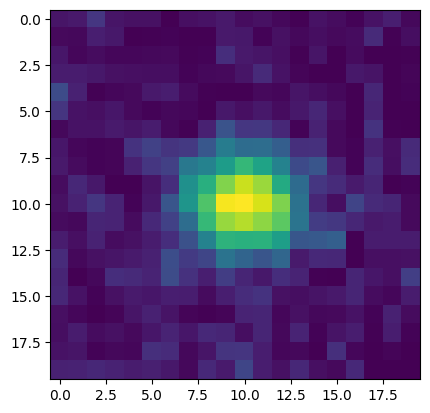

In [149]:
plt.imshow(image_crop)

X_train shape: (1600, 48, 128, 1)
y_train shape: (1600, 5, 5)
X_val shape: (400, 48, 128, 1)
y_val shape: (400, 5, 5)


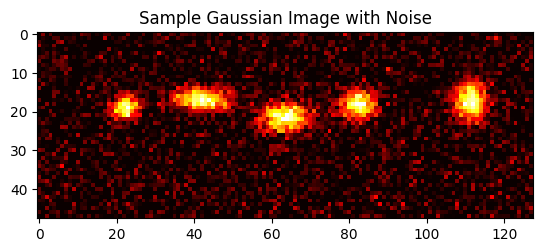

Sample Gaussian parameters (mean_x, mean_y, cov_x, cov_y, theta):
[[ 1.9815107e+01  2.1653032e+01  2.2215347e+00  4.7388344e+00
  -1.0141513e-01]
 [ 4.1333019e+01  2.5417145e+01  5.0553007e+00  4.3809371e+00
   1.3198902e-01]
 [ 6.6866920e+01  1.8088230e+01  5.0939102e+00  3.2124054e+00
   1.0245125e-01]
 [ 8.2433128e+01  2.1522707e+01  2.5163333e+00  2.7515786e+00
   2.2501705e-02]
 [ 1.0938933e+02  2.2167389e+01  4.5081263e+00  2.8709624e+00
   1.4980787e-01]]


In [224]:
# Generate the training data
num_samples = 2000
X, y = create_training_data(num_samples)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.reshape(X_train.shape[0], 48, 128, 1)
X_val = X_val.reshape(X_val.shape[0], 48, 128, 1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

# Visualize a sample image and its Gaussians
plt.imshow(X_train[0].squeeze(), cmap='hot')
plt.title("Sample Gaussian Image with Noise")
plt.show()

print("Sample Gaussian parameters (mean_x, mean_y, cov_x, cov_y, theta):")
print(y_val[0])

In [253]:
import tensorflow as tf

def make_gaussian_blob(image_shape, meanx, meany, covx, covy, theta, batch_size):
    """
    Generate a Gaussian blob for each image in the batch based on the given parameters.
    
    Args:
        image_shape (tuple): Shape of the image (height, width).
        meanx, meany: Tensor of shape (batch_size,) with the center of the Gaussian in normalized coordinates (0 to 1).
        covx, covy: Tensor of shape (batch_size,) with covariance along x and y.
        theta: Tensor of shape (batch_size,) with rotation angle of the Gaussian.
        batch_size: Number of images in the batch.

    Returns:
        A batch of 2D Gaussian blobs as a Tensor of shape (batch_size, height, width).
    """
    height, width = image_shape
    x = tf.linspace(0.0, 1.0, width)
    y = tf.linspace(0.0, 1.0, height)
    X, Y = tf.meshgrid(x, y)

    # Expand grid for the batch dimension
    X = tf.tile(X[None, :, :], [batch_size, 1, 1])  # Shape: (batch_size, height, width)
    Y = tf.tile(Y[None, :, :], [batch_size, 1, 1])  # Shape: (batch_size, height, width)

    # Convert meanx and meany from normalized coordinates to pixel coordinates
    meanx = meanx[:, None, None]  # Shape: (batch_size, 1, 1)
    meany = meany[:, None, None]  # Shape: (batch_size, 1, 1)

    # Compute the rotation matrix components
    cos_theta = tf.cos(theta)[:, None, None]  # Shape: (batch_size, 1, 1)
    sin_theta = tf.sin(theta)[:, None, None]  # Shape: (batch_size, 1, 1)

    # Shift X and Y grids according to the mean values
    X_shifted = X - meanx  # Shape: (batch_size, height, width)
    Y_shifted = Y - meany  # Shape: (batch_size, height, width)

    # Apply the rotation matrix
    X_rot = X_shifted * cos_theta + Y_shifted * sin_theta  # Shape: (batch_size, height, width)
    Y_rot = -X_shifted * sin_theta + Y_shifted * cos_theta  # Shape: (batch_size, height, width)

    # Create the 2D Gaussian for each image in the batch
    exponent = -0.5 * ((X_rot**2 / (covx[:, None, None]**2)) + (Y_rot**2 / (covy[:, None, None]**2)))
    gaussian_blob = tf.exp(exponent)  # Shape: (batch_size, height, width)
    gaussian_blob = tf.expand_dims(gaussian_blob, axis=-1)

    return gaussian_blob

def generate_gaussian_blob(image_size, mean, cov, angle, noise_std=0.01):
    """
    Generate a single Gaussian blob on an image with added random noise.
    """
    x, y = np.meshgrid(np.linspace(0, image_size[0] - 1, image_size[0]),
                       np.linspace(0, image_size[1] - 1, image_size[1]))
    x -= mean[0]
    y -= mean[1]

    cos_angle = np.cos(angle)
    sin_angle = np.sin(angle)

    x_rot = cos_angle * x + sin_angle * y
    y_rot = -sin_angle * x + cos_angle * y

    exponent = (x_rot ** 2) / (2 * cov[0] ** 2) + (y_rot ** 2) / (2 * cov[1] ** 2)
    blob = np.exp(-exponent)

    # Add random noise centered around the Gaussian blob
    noise = np.random.normal(0, noise_std, blob.shape)
    blob += noise

    return blob

def custom_unsupervised_loss(original_image, predicted_gaussian_params):
    """
    Custom unsupervised loss function that compares the original image with a
    reconstructed image generated from the predicted Gaussian parameters.
    
    Args:
        original_image: Tensor of shape (batch_size, 48, 128, 1).
        predicted_gaussian_params: Tensor of shape (batch_size, 5, 5), where each 5
                                   corresponds to (meanx, meany, covx, covy, theta) for a Gaussian.

    Returns:
        A scalar loss value.
    """
    batch_size = tf.shape(original_image)[0]
    height, width = 48, 128

    # Initialize the reconstructed image as zeros
    print(original_image.shape)
    reconstructed_image = tf.zeros_like(original_image)

    # Loop over each Gaussian prediction
    for i in range(5):
        # Extract the parameters for the i-th Gaussian
        meanx = predicted_gaussian_params[:, i, 0]
        meany = predicted_gaussian_params[:, i, 1]
        covx = predicted_gaussian_params[:, i, 2]
        covy = predicted_gaussian_params[:, i, 3]
        theta = predicted_gaussian_params[:, i, 4]

        # Generate the Gaussian blob for the entire batch
        gaussian_blob = make_gaussian_blob(
            image_shape=(height, width),
            meanx=meanx, meany=meany,
            covx=covx, covy=covy, theta=theta,
            batch_size=batch_size
        )

        # Add the Gaussian blob to the reconstructed image
        reconstructed_image += gaussian_blob # Add channel dimension
        
    reconstructed_image = tf.squeeze(reconstructed_image)
    plt.imshow(reconstructed_image)

    # Compute the Mean Squared Error (MSE) loss between original and reconstructed images
    loss = 1
    # tf.reduce_mean(tf.square(original_image - reconstructed_image))

    return loss

(1, 5, 5)
(1, 48, 128, 1)
1


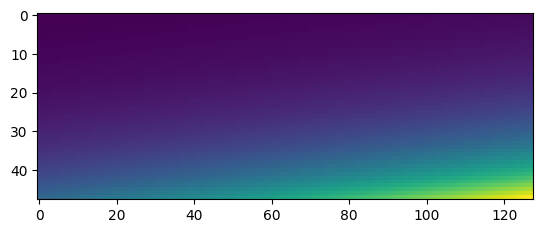

In [254]:
loss_test, loss_test_params = create_training_data(1)
print(loss_test_params.shape)

loss_result = custom_unsupervised_loss(loss_test, loss_test_params)

print(loss_result)


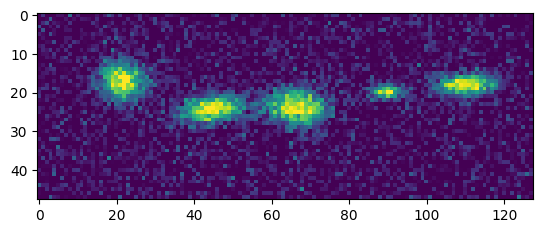

In [248]:
loss_test = tf.squeeze(loss_test)
plt.imshow(loss_test)

Epoch 1/40


NotImplementedError: Cannot convert a symbolic tf.Tensor (compile_loss/custom_unsupervised_loss/add_19:0) to a numpy array. This error may indicate that you're trying to pass a Tensor to a NumPy call, which is not supported.

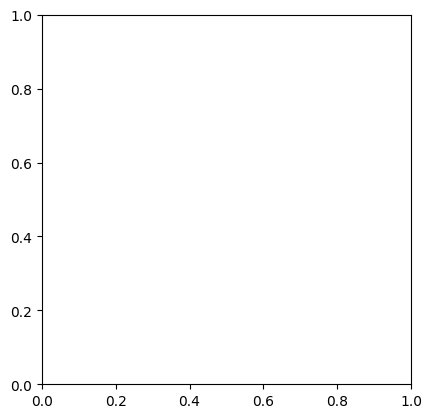

In [227]:
# Compile the model with the custom loss function
input_shape = (48, 128, 1)
model = GaussianFitter(input_shape)
model.compile(optimizer='adam', loss=custom_unsupervised_loss)

# Example usage
history = model.fit(
    X_train, X_train,  # Unsupervised training, so X_train is both input and target
    validation_data=(X_val, X_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)

In [198]:
model.summary()

Model: "gaussian_fitter_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_182 (Conv2D)             │ (32, 24, 64, 8)        │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_138               │ (32, 12, 32, 8)        │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_183 (Conv2D)             │ (32, 6, 16, 16)        │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_139               │ (32, 3, 8, 16)         │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (32, 64)               │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (32, 25)               │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,541 (322.43 KB)

 Trainable params: 27,513 (107.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 55,028 (214.96 KB)

In [178]:
X_test, y_test = create_training_data(1)
y_pred, crop_boxes = model.predict(X_test)
print(y_pred.shape)




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
(1, 5)


In [161]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_gaussians_from_predictions(predictions, image_shape=(48, 128), threshold=0.1):
    # Create an empty image
    image = np.zeros((image_shape[0], image_shape[1]), dtype=np.float32)

    for x in range(5):
        meanx, meany, covx, covy, theta = predictions[x][:]

        # Only plot if covx and covy are noticeably above the threshold
        if covx > threshold and covy > threshold:
            # Draw the Gaussian blob on the image
            draw_blob(image, meanx, meany, covx, covy, theta)

    # Convert BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(image_rgb)
    plt.title('Generated Gaussians from Predictions')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
    plt.show()

def draw_blob(image, meanx, meany, covx, covy, theta):
    blob = generate_gaussian_blob((128, 48), (meanx, meany), (covx, covy), theta, 0)
    image += blob

(5, 5)


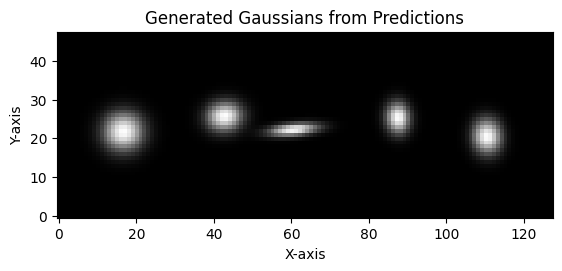

In [162]:
print(y_test.shape)
plot_gaussians_from_predictions(y_test)

In [165]:
plot_gaussians_from_predictions(y_pred)

IndexError: index 1 is out of bounds for axis 0 with size 1